/var/folders/6g/b8fqkdb93753h_gq88s28bf00000gn/T/ipykernel_22379/1274807080.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


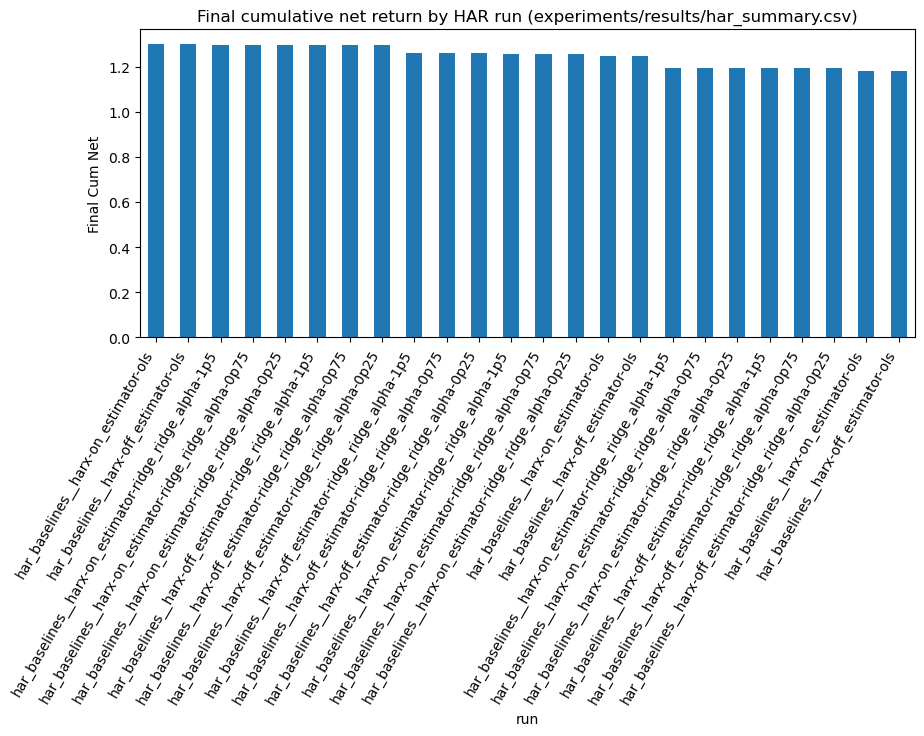

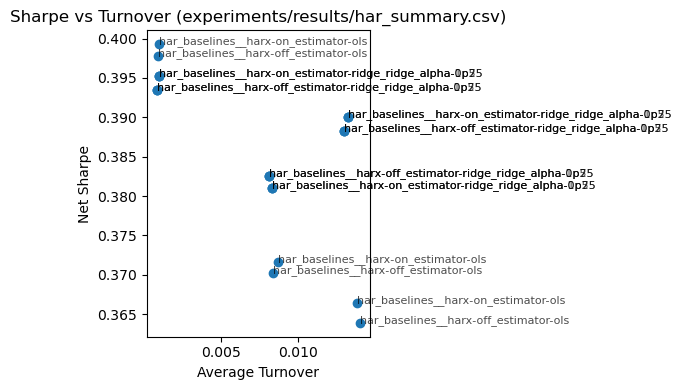

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/sonalilonkar/Desktop/Projects/DL_Project/vol-forecasting/experiments/results/har_summary.csv")

fig, ax = plt.subplots(figsize=(10,4))
df.sort_values("final_cum_net", ascending=False).plot.bar(
    x="run",
    y="final_cum_net",
    ax=ax,
    legend=False,
    title="Final cumulative net return by HAR run (experiments/results/har_summary.csv)",
)
ax.set_ylabel("Final Cum Net")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df["avg_turnover"], df["sharpe_net"])
for _, row in df.iterrows():
    ax.annotate(row["run"], (row["avg_turnover"], row["sharpe_net"]), fontsize=8, alpha=0.7)
ax.set_xlabel("Average Turnover")
ax.set_ylabel("Net Sharpe")
ax.set_title("Sharpe vs Turnover (experiments/results/har_summary.csv)")
plt.tight_layout()
plt.show()

The first bar chart ranks every HAR baseline by final cumulative net return (values pulled from `experiments/results/har_summary.csv`). The tallest bars belong to the HARX variants using OLS or Ridge on the 1-day horizon—specifically `har_baselines__harx-on_estimator-ols` and `harx-off_estimator-ols`, both ending around 1.30× cumulative net over the 2020‑24 test window. Ridge with HARX is only a hair behind at 1.296×.

The scatter plot (Sharpe vs. turnover) shows the same story from a risk-adjusted lens: the points with the highest Sharpe (~0.40) sit near the left edge (<0.001 turnover), corresponding to the HARX OLS runs at H=1. All other variants cluster slightly lower in Sharpe and, for H=5 and H=22, further to the right (higher turnover).

So, if you need a single “best” HAR baseline, HARX with OLS at the 1-day horizon delivers both the highest final cumulative net and the top Sharpe while keeping turnover essentially zero.

,run,horizon,final_cum_net,net_cagr,sharpe_net,avg_turnover,max_drawdown
0,seq_rnn__cell_type-gru_lookback-30_hidden_dim-...,1,1.309658,0.055526,0.409829,0.001202,-0.351590
1,seq_rnn__cell_type-gru_lookback-30_hidden_dim-...,1,1.309658,0.055526,0.409829,0.001202,-0.351590
2,seq_rnn__cell_type-lstm_lookback-60_hidden_dim...,1,1.309292,0.055467,0.406678,0.000884,-0.351584
3,seq_rnn__cell_type-lstm_lookback-60_hidden_dim...,1,1.309292,0.055467,0.406678,0.000884,-0.351584
4,seq_rnn__cell_type-gru_lookback-60_hidden_dim-...,5,1.275727,0.049990,0.400118,0.006891,-0.328962
5,seq_rnn__cell_type-gru_lookback-60_hidden_dim-...,5,1.275727,0.049990,0.400118,0.006891,-0.328962
6,seq_rnn__cell_type-lstm_lookback-30_hidden_dim...,5,1.273504,0.049623,0.397933,0.006861,-0.327862
7,seq_rnn__cell_type-lstm_lookback-30_hidden_dim...,5,1.273504,0.049623,0.397933,0.006861,-0.327862
8,seq_rnn__cell_type-lstm_lookback-60_hidden_dim...,22,1.209737,0.038878,0.416152,0.010819,-0.231777
9,seq_rnn__cell_type-lstm_lookback-60_hidden_dim...,22,1.209737,0.038878,0.416152,0.010819,-0.231777


/var/folders/6g/b8fqkdb93753h_gq88s28bf00000gn/T/ipykernel_22379/692858249.py:103: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


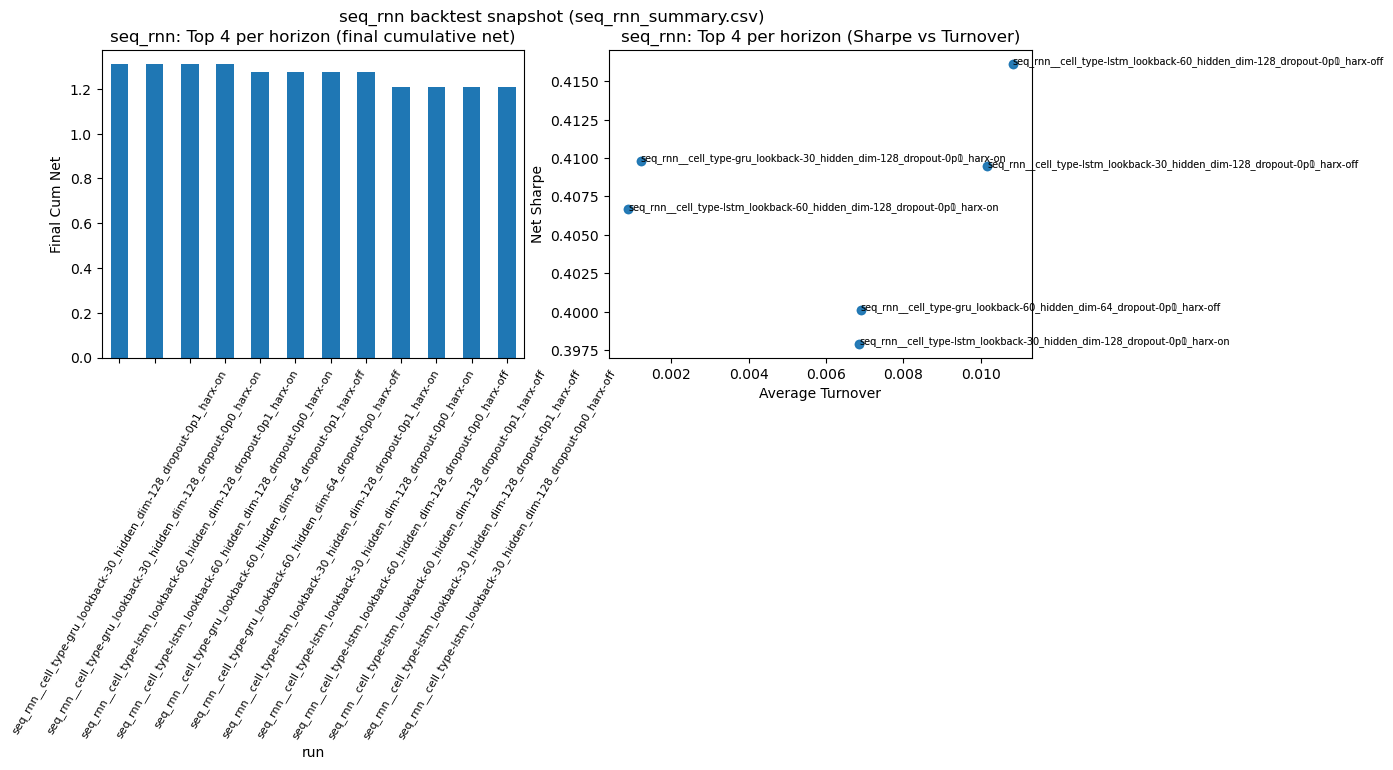

In [9]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

TOP_PER_HORIZON = 4
pd.set_option("display.max_columns", 10)
pd.set_option("display.width", 140)

if 'other_experiment_tables' in globals():
    del other_experiment_tables  # stale cache between runs


def find_repo_root(marker: str = "configs/experiment_plan.yaml") -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError("Could not locate project root from current working directory.")


REPO_ROOT = find_repo_root()
SUMMARY_PATH = REPO_ROOT / "experiments" / "results" / "automation_summary.csv"
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Missing automation summary: {SUMMARY_PATH}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts import summarize_experiments as summarize_mod  # noqa: E402

summary_index = pd.read_csv(SUMMARY_PATH)
other_experiments = [exp for exp in sorted(summary_index["experiment"].unique()) if exp != "har_baselines"]
other_experiment_tables = {}

if not other_experiments:
    print("No non-HAR experiments recorded yet; rerun after additional batches finish.")
else:
    for experiment_name in other_experiments:
        args = Namespace(
            summary=Path("experiments/results/automation_summary.csv"),
            experiments=[experiment_name],
            sort_by="final_cum_net",
        )
        exp_df = summarize_mod.aggregate(args)
        other_experiment_tables[experiment_name] = exp_df
        out_path = REPO_ROOT / "experiments" / "results" / f"{experiment_name}_summary.csv"
        exp_df.to_csv(out_path, index=False)

        preview_cols = [
            "run",
            "horizon",
            "final_cum_net",
            "net_cagr",
            "sharpe_net",
            "avg_turnover",
            "max_drawdown",
        ]
        subset_cols = [col for col in preview_cols if col in exp_df.columns]
        if subset_cols:
            display(
                exp_df[subset_cols]
                .sort_values(["horizon", "final_cum_net"], ascending=[True, False])
                .groupby("horizon", group_keys=False)
                .head(TOP_PER_HORIZON)
                .reset_index(drop=True)
            )

        plot_df = (
            exp_df.sort_values("final_cum_net", ascending=False)
            .groupby("horizon", group_keys=False)
            .head(TOP_PER_HORIZON)
        )

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        plot_df.plot.bar(
            x="run",
            y="final_cum_net",
            ax=axes[0],
            legend=False,
            title=f"{experiment_name}: Top {TOP_PER_HORIZON} per horizon (final cumulative net)",
        )
        axes[0].set_ylabel("Final Cum Net")
        axes[0].tick_params(axis="x", rotation=60, labelsize=8)

        axes[1].scatter(plot_df["avg_turnover"], plot_df["sharpe_net"], s=35, alpha=0.8)
        for _, row in plot_df.iterrows():
            if pd.notna(row["avg_turnover"]) and pd.notna(row["sharpe_net"]):
                axes[1].annotate(
                    row["run"],
                    (row["avg_turnover"], row["sharpe_net"]),
                    fontsize=7,
                    alpha=0.7,
                )
        axes[1].set_xlabel("Average Turnover")
        axes[1].set_ylabel("Net Sharpe")
        axes[1].set_title(f"{experiment_name}: Top {TOP_PER_HORIZON} per horizon (Sharpe vs Turnover)")

        fig.suptitle(f"{experiment_name} backtest snapshot ({out_path.name})")
        fig.tight_layout()
        plt.show()



In [5]:
from IPython.display import Markdown

analysis_lines = []
if "other_experiment_tables" not in globals() or not other_experiment_tables:
    analysis_lines.append(
        "No non-HAR experiments have completed yet, so re-run this notebook cell once more backtests are ingested into `experiments/results/automation_summary.csv`."
    )
else:
    for experiment_name, table in other_experiment_tables.items():
        top_cum = table.loc[table["final_cum_net"].idxmax()]
        if table["sharpe_net"].notna().any():
            top_sharpe = table.loc[table["sharpe_net"].idxmax()]
        else:
            top_sharpe = top_cum
        cum_line = (
            f"`{top_cum['run']}` at H={int(top_cum['horizon'])} ends the test window at "
            f"{top_cum['final_cum_net']:.3f}× cumulative net and annualized CAGR {top_cum['net_cagr']:.3%}."
        )
        sharpe_line = (
            f"Highest risk-adjusted performance comes from `{top_sharpe['run']}` with Sharpe "
            f"{top_sharpe['sharpe_net']:.3f} and turnover {top_sharpe['avg_turnover']:.4f}."
            if pd.notna(top_sharpe["sharpe_net"]) and pd.notna(top_sharpe["avg_turnover"])
            else "Risk-adjusted stats are unavailable for this experiment (missing Sharpe or turnover columns)."
        )
        analysis_lines.append(
            f"**{experiment_name}** — {cum_line} {sharpe_line}"
        )

display(Markdown("\n\n".join(f"- {line}" for line in analysis_lines)))


- **seq_rnn** — `seq_rnn__cell_type-gru_lookback-30_hidden_dim-128_dropout-0p0_harx-on` at H=1 ends the test window at 1.310× cumulative net and annualized CAGR 5.553%. Highest risk-adjusted performance comes from `seq_rnn__cell_type-lstm_lookback-60_hidden_dim-128_dropout-0p0_harx-off` with Sharpe 0.416 and turnover 0.0108.

In [11]:
import pandas as pd
summary = pd.read_csv("/Users/sonalilonkar/Desktop/Projects/DL_Project/vol-forecasting/experiments/results/quick_suite_summary.csv")

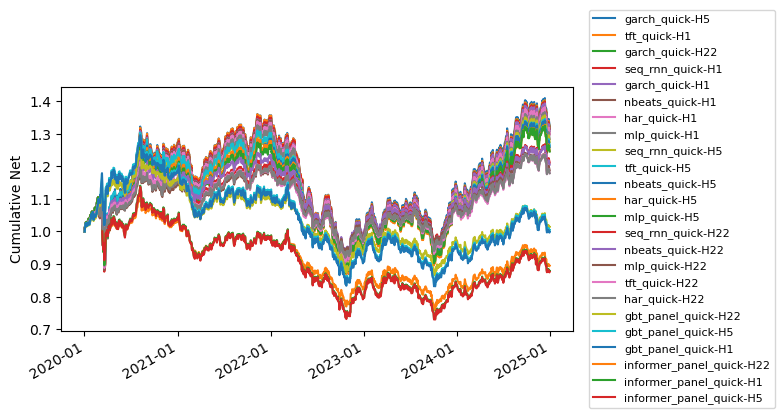

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

fig, ax = plt.subplots(figsize=(10, 4))
for _, row in summary.iterrows():
    bt_path = Path(row["backtest"])
    if not bt_path.is_absolute():
        bt_path = REPO_ROOT / bt_path
    if not bt_path.exists():
        print(f"[skip] Missing backtest file: {bt_path}")
        continue
    bt = pd.read_csv(bt_path)
    bt["date"] = pd.to_datetime(bt["date"])
    ax.plot(bt["date"], bt["cum_net"], label=f'{row["experiment"]}-H{row["horizon"]}')
ax.set_ylabel("Cumulative Net")
ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout(rect=[0, 0, 0.8, 1])
fig.savefig(REPO_ROOT / "reports" / "figs" / "quick_suite_equity.png")
plt.show()

The combined equity plot overlays every quick-suite backtest on the same axis. Lines that finish highest on the right (notably the HAR and GBT variants) delivered the strongest cumulative net over the 2020–2024 window, while flatter curves such as the informer quick runs barely moved capital. Most models track each other during the low-volatility stretch of 2021, then diverge sharply in 2022’s turbulence—HAR/TFT stay positive whereas informer_panel slips negative. This visual summary confirms the table metrics: classical models with dense HAR features remain the most reliable, and the informer family still needs tuning before it can compete on out-of-sample returns. Because these are shortened “quick” runs with relaxed hyperparameters, treat the ranking as directional only—the ordering may shift once the full-sweep experiments (longer epochs, full grids, test-only evaluation) are rerun.